In [1]:
import jax 
import jax.numpy as jnp

from probjax.inference.mcmc import MCMC
from probjax.inference.marcov_kernels import HMCKernel, GaussianMHKernel, SliceKernel, LangevianMHKernel

import seaborn as sns
import pandas as pd
from functools import partial

from probjax.core import joint_sample, log_potential_fn, rv, intervene, JaxprGraph
from probjax.distributions import Normal 
from probjax.utils.jaxutils import ravel_args

In [168]:
def model(key):
    key1, key2, key3, key4 = jax.random.split(key, 4)
    theta1 = rv(Normal(jnp.zeros((1,)), 3.), name = "theta1")(key1)
    theta2 = rv(Normal(jnp.zeros((1,)), 3.), name = "theta2")(key2)
    z1 = jnp.sin(theta1)*2
    z2 = theta2**2
    x1 = rv(Normal(z1, 0.5), name = "x1")(key3)
    x2 = rv(Normal(0.1 * z2 + z1, 0.5), name = "x2")(key4)
    x3 = rv(Normal(jnp.cos(x2), 1.), name = "x3")(key4)
    
    
    

In [169]:
key = jax.random.PRNGKey(1)

joint_sampler = joint_sample(model)
potential_fn = log_potential_fn(joint_sampler)

In [170]:
var_names = ["theta1", "theta2", "x1", "x2", "x3"]

In [171]:
@partial(jax.vmap, in_axes = [0, None, None])
def sample_fn(key, condition_mask, x_o):

    conditioned_names = [var_names[i] for i in range(len(var_names)) if condition_mask[i]]
    conditioned_nodes = {var: val for var, val in zip(conditioned_names, x_o)}


    init_vals = joint_sampler(key)

    for var in conditioned_nodes:
        del init_vals[var]
    
    

    init_vals_flat, unravel = ravel_args(init_vals)
    
    print(init_vals_flat.shape)
    sampler = intervene(joint_sampler, conditioned_nodes)
    potential_fn = log_potential_fn(sampler)


    @jax.jit
    def potential_fn_wrapper(vals):
        vals = unravel(vals)
        return potential_fn(**vals)

    mcmc = MCMC(HMCKernel(), potential_fn_wrapper)
    state = mcmc.init_state(key, init_vals_flat)
    samples, state = mcmc.run(state, 5000)
    return samples

In [176]:
x_o = jnp.stack(jax.tree_util.tree_flatten(joint_sampler(key))[0])

In [177]:
x_o

Array([[ 4.735],
       [-7.597],
       [-1.786],
       [ 3.277],
       [-1.98 ]], dtype=float32)

In [178]:
condition_mask = jnp.array([0, 0, 0,1, 0], dtype = bool)
samples = sample_fn(jax.random.split(key, (jnjjax jax asd adf sadf sadf safdnjjasdfjkasdfklsadjkfjaxasdfjasdfkasdfkjlsadf,)), condition_mask, x_o)

(4,)


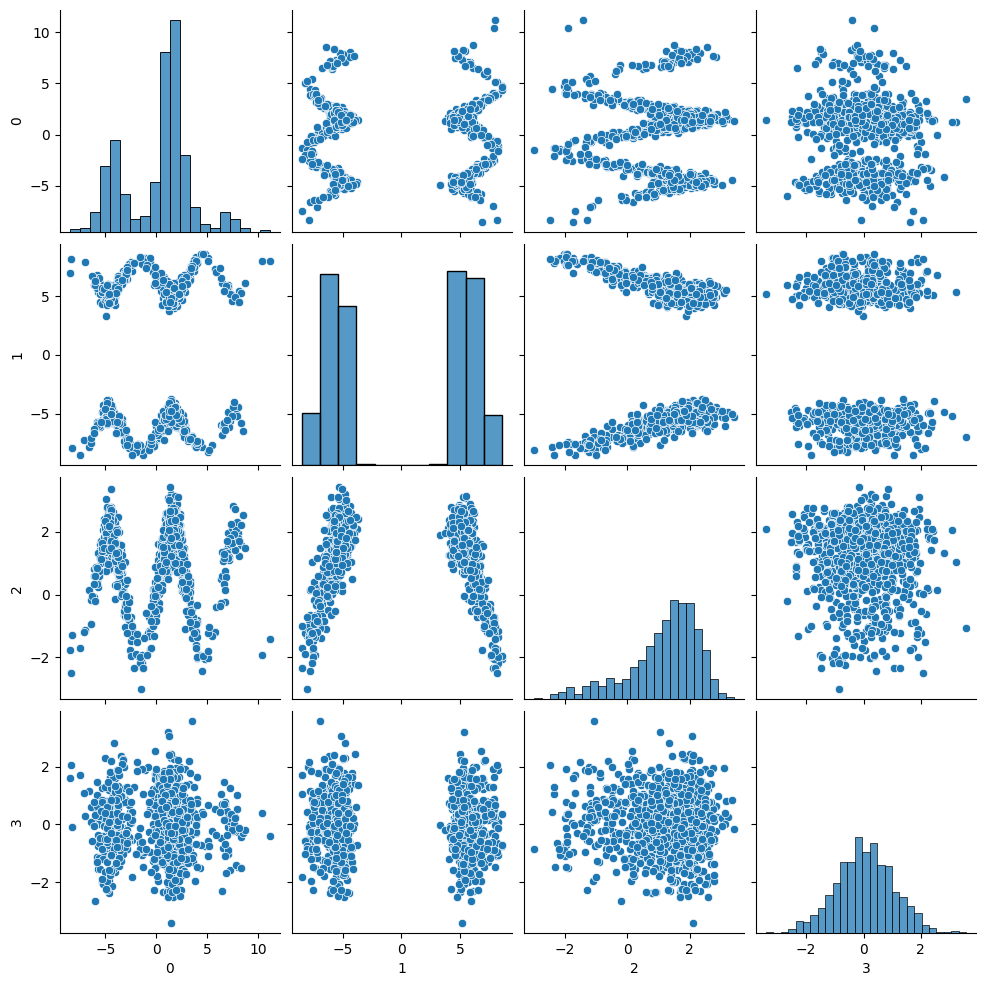

In [179]:
sns.pairplot(pd.DataFrame(samples))

In [180]:
from jax.flatten_util import ravel_pytree

In [145]:
samples = jax.vmap(joint_sampler)(jax.random.split(key, (1000,)))
samples = jnp.stack(jax.tree_flatten(samples)[0]).T

/tmp/ipykernel_9012/3065718851.py:2: DeprecationWarning: jax.tree_flatten is deprecated: use jax.tree_util.tree_flatten.
  samples = jnp.stack(jax.tree_flatten(samples)[0]).T


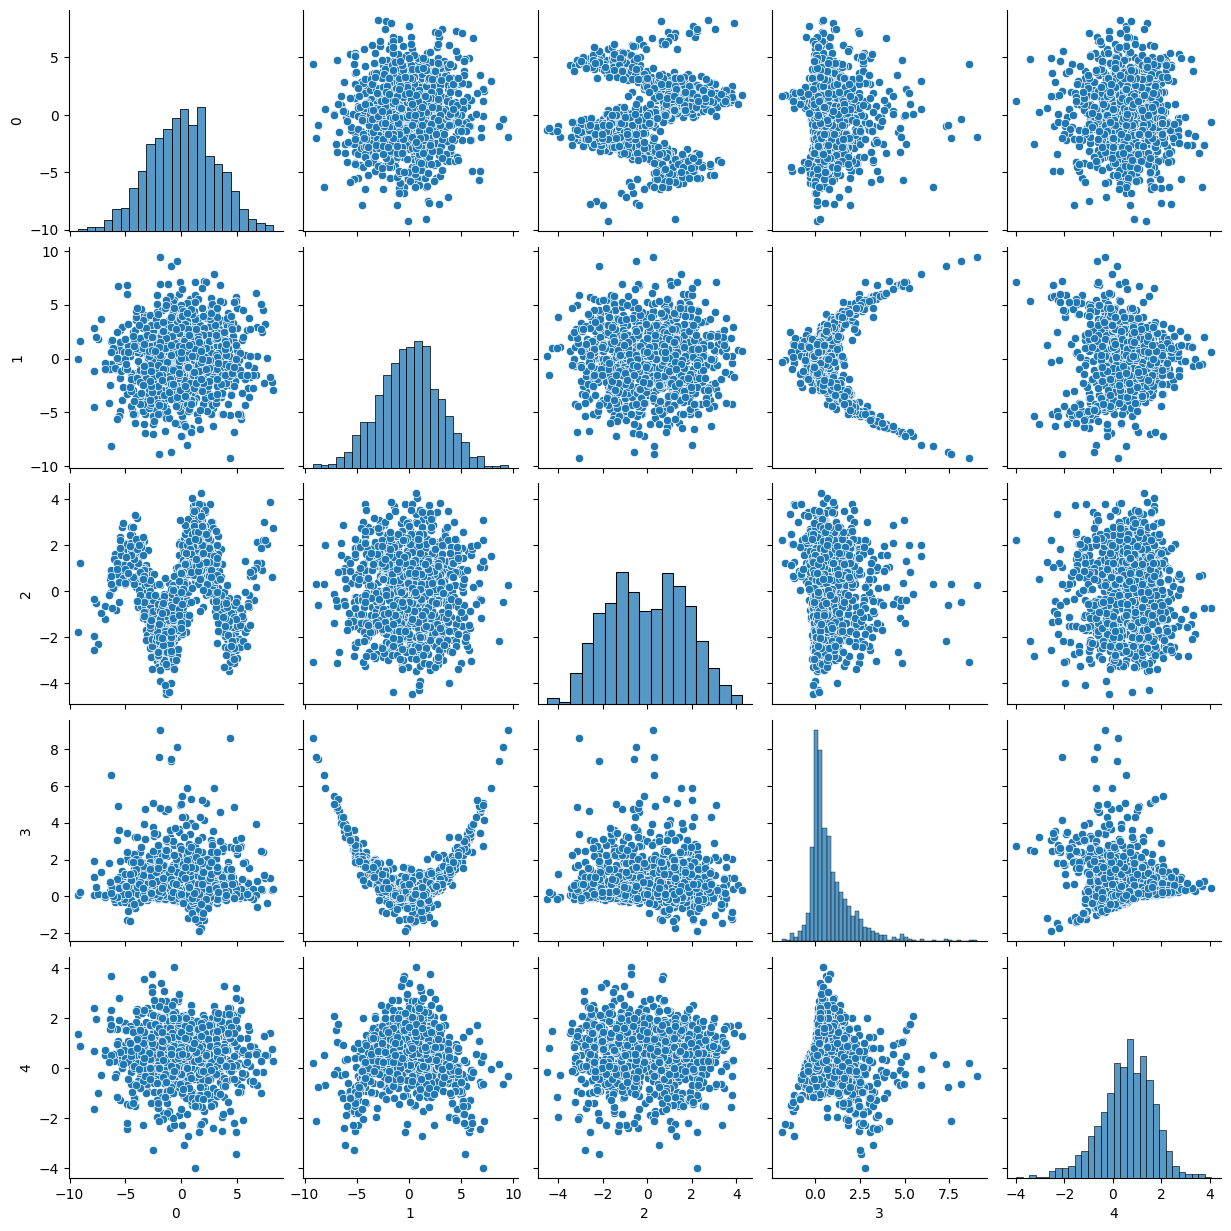

In [149]:
sns.pairplot(pd.DataFrame(samples[0]))